<a href="https://colab.research.google.com/github/jayasuneja/FWE458_Spring25/blob/main/Homework9_Suneja/Homework9_Suneja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 9: Machine Learning for Solar Radiation Prediction
Jaya Suneja

## Background Story
You are a machine learning engineer working with atmospheric scientists to better understand how solar radiation is impacted by atmospheric conditions. Your dataset, SW_with_AOD.csv, contains observed surface radiation and related atmospheric properties such as aerosol optical depth (AOD), cloud fraction, total ozone, and surface reflectance.

Your task is to build models to predict the amount of incoming shortwave radiation and to categorize total incoming radiation into groups using clustering and classification techniques.

# Part 1: Data Preprocessing (1 Point)

In [5]:
# Load data: SW_with_AOD.csv
from google.colab import drive
drive.mount('/content/drive')

filedir = '/content/drive/MyDrive/FWE458/'
fname = filedir + "SW_with_AOD.csv"

import pandas as pd
df = pd.read_csv(fname)
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,SZA,AOD,COD,CLD_FRAC,UW,TO3,Pressure,BSA,WSA,SW_direct,SW_diffuse
0,24.936783,1.172892,2.440000,0.286546,2.021502,311.419861,959.085083,0.162,0.193,467.191650,300.820007
1,34.865055,1.626954,4.630000,0.468832,4.859887,308.713379,968.427551,0.155,0.169,264.900024,385.293335
2,27.330978,1.095007,2.030000,0.301414,5.278558,293.322052,988.040588,0.136,0.149,313.553314,321.538361
3,20.361732,1.126541,5.500000,0.377019,4.856422,321.498199,977.610229,0.156,0.179,143.902298,501.073639
4,13.433228,0.725452,0.736076,0.075378,0.644262,295.448975,882.321411,0.188,0.212,957.331665,79.003334
...,...,...,...,...,...,...,...,...,...,...,...
35219,37.315063,0.181112,2.360000,0.071185,2.312875,268.948242,970.049805,0.146,0.171,474.672302,207.633331
35220,64.573303,0.258045,0.392416,0.060352,0.893602,328.640442,988.746948,0.135,0.132,382.056671,74.483337
35221,61.829556,0.138252,0.233040,0.033619,2.335012,259.676788,970.049805,0.146,0.171,115.962257,281.266663
35222,67.391891,0.698632,1.368286,0.218022,0.462143,265.180176,811.828369,0.192,0.183,385.561645,50.876663


Data description:
* SZA = Solar Zenith Angle
* AOD = Aerosol Optical Depth
* COD = Cloud Optical Depth
* CLD_FRAC = Cloud Fraction
* UW = Water Vapor Column
* TO3 = Total Ozone
* Pressure = Surface Pressure
* BSA = Black Sky Albedo
* WSA = White Sky Albedo

Targets:
* SW_direct = Direct Shortwave Radiation
* SW_diffuse = Diffuse Shortwave Radiation

SZA            0
AOD            0
COD            0
CLD_FRAC       0
UW             0
TO3            0
Pressure       0
BSA            0
WSA            0
SW_direct      0
SW_diffuse     0
SW_total       0
SW_quartile    0
dtype: int64
         SZA       AOD       COD  CLD_FRAC        UW         TO3    Pressure  \
0  24.936783  1.172892  2.440000  0.286546  2.021502  311.419861  959.085083   
1  34.865055  1.626954  4.630000  0.468832  4.859887  308.713379  968.427551   
2  27.330978  1.095007  2.030000  0.301414  5.278558  293.322052  988.040588   
3  20.361732  1.126541  5.500000  0.377019  4.856422  321.498199  977.610229   
4  13.433228  0.725452  0.736076  0.075378  0.644262  295.448975  882.321411   

     BSA    WSA   SW_direct  SW_diffuse     SW_total SW_quartile  
0  0.162  0.193  467.191650  300.820007   768.011658          Q3  
1  0.155  0.169  264.900024  385.293335   650.193359          Q3  
2  0.136  0.149  313.553314  321.538361   635.091675          Q2  
3  0.156  0.179  

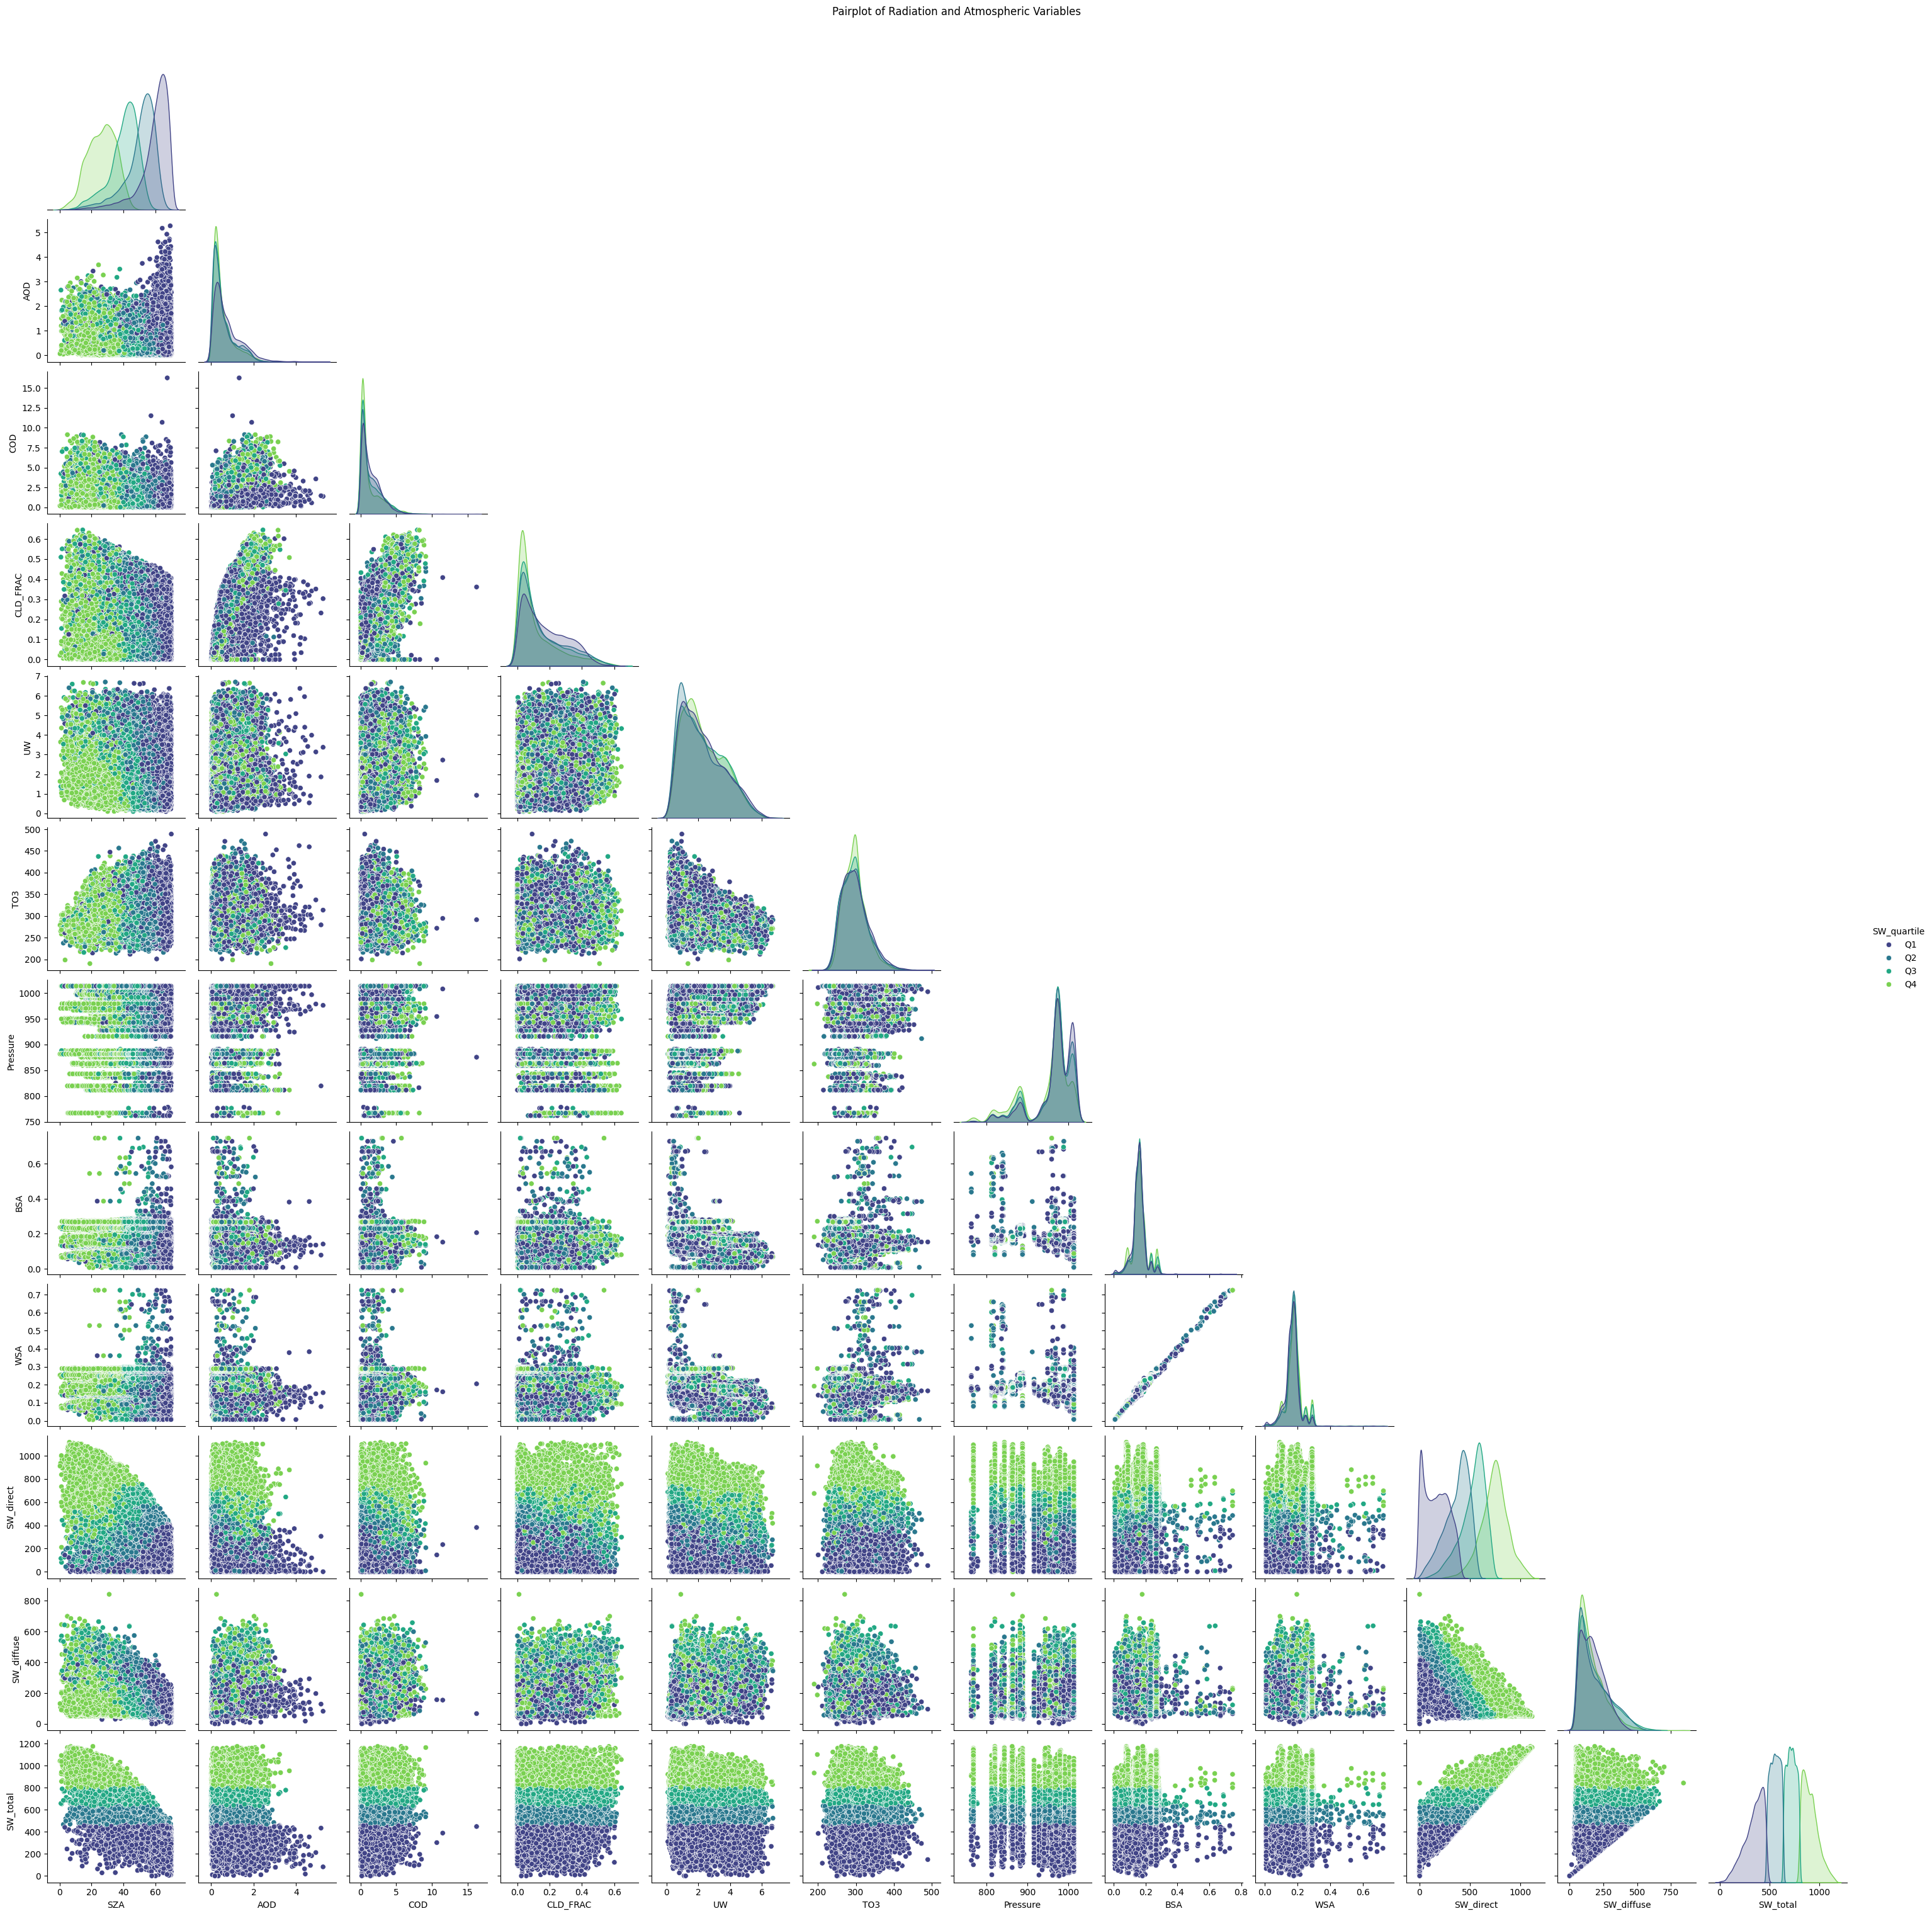

In [12]:
# Importing packages (added as I went along)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Setting up parameters (X) and targets (SW_total)
X = df[["SZA", "AOD", "COD", "CLD_FRAC", "UW", "TO3", "Pressure", "BSA", "WSA"]]

# Creating a new column of the sum of direct and diffuse SW radiation
df["SW_total"] = df["SW_direct"] + df["SW_diffuse"]

# Check for missing values in both sets
print(df.isnull().sum())  # this returned no missing values, so we're good!

# Creating a categorical column of quartiles of SW_total
df["SW_quartile"] = pd.qcut(df["SW_total"], q=4, labels = ["Q1", "Q2", "Q3", "Q4"])
print(df.head())  # checking to make sure the quartile line worked



# Visual Exploration with Pairplot

# Selecting which features to put into pairplot
features = ["SZA", "AOD", "COD", "CLD_FRAC", "UW", "TO3", "Pressure", "BSA", "WSA", "SW_direct", "SW_diffuse", "SW_total"]

# Creating the pairplot
sns.pairplot(df[features + ["SW_quartile"]], hue = "SW_quartile", corner = True, palette= "viridis")
plt.suptitle("Pairplot of Radiation and Atmospheric Variables", y =1.02)
plt.show()

# Part 2: Unsupervised Learning - Radiation Pattern Clustering (3 points)

## 2.1 K-Means Clustering (2 points)


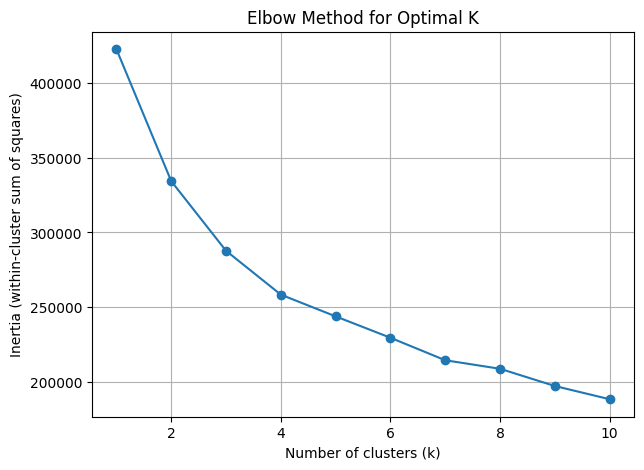

In [13]:
# Use the normalized input features (exclusing any SW variables) for K-Means clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(7, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

# based on the graph, the optimal K is about 3 because after this value, the graph flattens out.

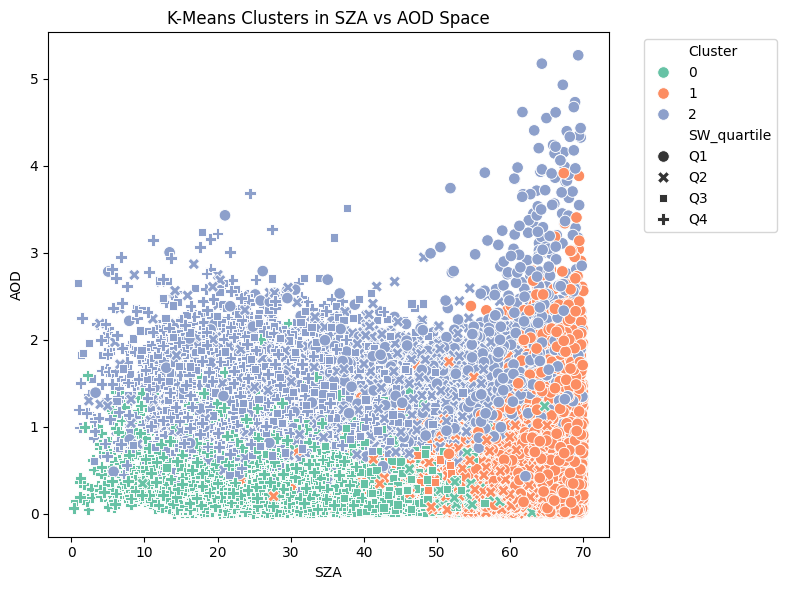

In [16]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="SZA", y="AOD", hue="Cluster", palette="Set2", style="SW_quartile", s=70)
plt.title("K-Means Clusters in SZA vs AOD Space")
plt.xlabel("SZA")
plt.ylabel("AOD")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
# Here, I am using an alignment table to see if the clusters determined using K-means aligns with the SW_total quartiles
alignment_table = pd.crosstab(df["Cluster"], df["SW_quartile"])
print(alignment_table)

SW_quartile    Q1    Q2    Q3    Q4
Cluster                            
0              24   734  5473  7187
1            6848  5776   851     2
2            1934  2296  2482  1617


## 2.1 Interpretation (1 point)
In my alignment table:
* Cluster 0 is dominated by Q3 and Q4 values
* Cluster 1 is mostly Q1 and Q2 values
* Cluster 2 is pretty evenly spread across all quartiles, but has the most in Q3 and the least in Q4

In my figure above:
* Cluster 0 is very low in AOD (Aerosol Optical Depth) and spread out along SZA (Solar Zenith Angle)
* Cluster 1 is very high SZA and spread out across AOD
* Cluster 2 was put in mostly in middle of SZA and AOD

This means that:
* Clear alignment for Cluster 0 being high radiation
* Clear alignment for Cluster 1 being low radiation
* This means that overall, the unsupervised categorization succesfully captured that the lower quartiles are the lower radiation and the upper quartiles being high radiation, putting them in clusters 0 or 1.

# Part 3: Supervised Learning - Predicting Solar Radiation (4 points)


## 3.1 Regression - Predicting SW_total (2 points)



In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Defining inputs
features = ["SZA", "AOD", "COD", "CLD_FRAC", "UW", "TO3", "Pressure", "BSA", "WSA"]
X = df[features]
y = df["SW_total"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Decision Tree Regression
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree - RMSE: {rmse_dt:.2f}, R²: {r2_dt:.3f}")

Decision Tree - RMSE: 140.18, R²: 0.601


In [33]:
# Random Forest Regression
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - RMSE: {rmse_rf:.2f}, R²: {r2_rf:.3f}")

Random Forest - RMSE: 99.05, R²: 0.801


<ipython-input-34-6512c67a31f5>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


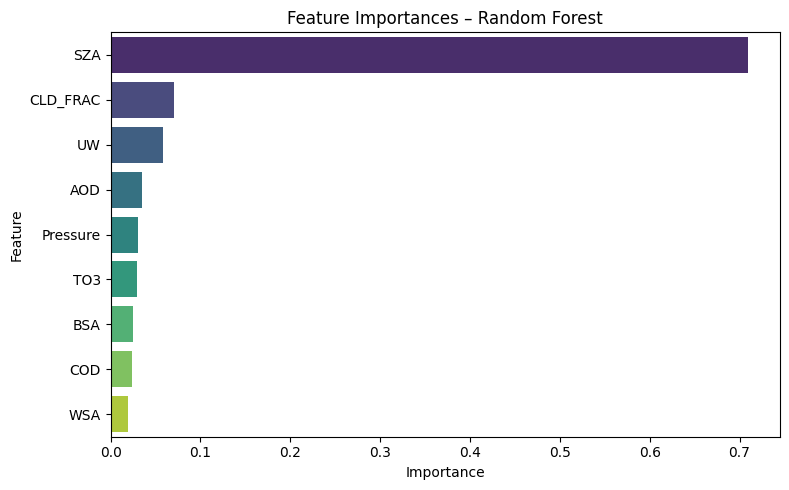

In [34]:
# Interpret the importances from the random forest model
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Feature Importances – Random Forest")
plt.tight_layout()
plt.show()

My RMSE/R-squared values are:
* Decision Tree: 140.18 / 0.601
* Random Forest: 99.05 / 0.801

The Random Forest outperforms the Decision Tree regression because of the lower RMSE value and higher R-squared value.

The most according to the feature importance analysis, SZA, CLD_FRAC, and UW are the most important features for determining total solar radiation, with SZA appearing far more important than any other feature.

# Part 4: Reflection and Recommendation (2 points)

In this analysis, total shortwave radiation (SW_total) was predicted using atmospheric and surface variables (features). The Random Forest Regressor significantly outperformed the Decision Tree model, achieving an RMSE of 99.05 and an R² of 0.801, indicating strong predictive performance compared to the Decision Tree Model.

Feature importance analysis revealed that Solar Zenith Angle (SZA) is the most influential factor, contributing the majority of the model's predictive power. Other moderately important features include cloud fraction (CLD_FRAC) and precipitable water vapor (UW), highlighting the role of atmospheric transparency and moisture in controlling incoming solar radiation.

Unsupervised K-Means clustering revealed distinct groups aligned with SW_total quartiles. One cluster predominantly captured low-radiation conditions (Q1–Q2), while another represented high-radiation scenarios (Q3–Q4), suggesting that atmospheric patterns can segment typical radiation regimes even without direct solar input.

Based on these results, a Random Forest model using key atmospheric predictors (especially SZA, cloud properties, and water vapor) is recommended for total solar radiation prediction. It captures nonlinear interactions and provides interpretable insights via feature importance, making it easy in scientific interpretation.